# 📊 선박 도장 품질 데이터셋 탐색적 데이터 분석 (EDA)

## 1. 개요 (Overview)
본 노트북은 AI-Hub의 **선박 도장 품질 측정 데이터**를 활용하여, 온디바이스(Edge) 감리 지원 시스템 학습에 사용할 핵심 데이터셋의 통계적 분포를 분석하고 학습용 마스터 데이터를 구축합니다. 

제조업 데이터 특성상 정상 데이터와 불량 데이터 간의 극단적인 **데이터 불균형(Class Imbalance)**이 예상되므로, 이를 정량적으로 확인하고 향후 모델(Swin-YOLO26) 학습 시 적용할 데이터 통제 전략을 수립하는 것이 목적입니다.

## 2. 분석 대상 클래스 (Target Classes)
본 연구에서는 아래 **8개 클래스**만을 선별하여 분석합니다.

* **[101]** 정상 (Normal)
* **[201]** 워터스포팅 (Water Spotting)
* **[202]** 흐름 (Sagging)
* **[203]** 도막분리 (Peeling)
* **[204]** 핀홀 (Pinhole)
* **[205]** 균열 (Crack)
* **[206]** 부풀음 (Blistering)
* **[207]** 이물질포함 (Inclusion)

## 3. 주요 분석 목표 및 작업 계획 (Objectives & Plan)

**① 데이터 수량 및 누락 검증 (Sanity Check)**
* 선별된 양품 폴더 4개와 불량 폴더 7개의 이미지 파일 수량을 집계하여, AI-Hub 공식 데이터셋 통계량과 일치하는지 누락 여부를 교차 검증합니다.

**② 불균형 통제(Under-sampling) 기준점 설정**
* 불량 폴더 중 가장 이미지 파일 수가 적은 소수 클래스(예: 균열 약 5,800장 예상)를 특정하여, 데이터 증강 및 언더샘플링의 하한선으로 삼습니다.

**③ 데이터셋 분할 비율 확정**
* 모델의 객관적인 성능 평가를 위해 학습(Train) : 검증(Validation) : 성능평가(Test) 데이터셋의 배분 비율을 결정합니다.

**④ 통합 라벨링 마스터 파일 구축 (`ship_paint_annotations.csv`)**
* 복잡한 폴더 구조에 흩어진 JSON 파일들을 일괄 파싱하여 모델 학습 파이프라인에 즉시 투입 가능한 단일 CSV 파일로 경량화합니다.
* **[추출 타겟 필드]**
  * `images`: `id` (통계적 분포 평탄화 및 분할 추출용), `width`, `height`, `file_name`
  * `annotations`: `id`, `image_id`, `category_id`, `bbox` (x, y, w, h), `attributes.quality` (양품/불량품 텍스트)

## 💻 3-①. 폴더 구조 스캔 및 Sanity Check (ID 정렬 및 이미지-JSON 매칭 검증)

In [1]:
import os
import pandas as pd
from collections import defaultdict

# 1. 데이터셋 최상위 경로 지정
DATASET_ROOT = '../data/01-1.정식개방데이터' 

# 2. 카테고리 ID와 클래스명 매핑 (학습 명세서 기준)
# 형태: '키워드': (카테고리ID, '클래스명')
target_mapping = {
    '외판': (101, '정상(Normal)'), '선수': (101, '정상(Normal)'), 
    '선미': (101, '정상(Normal)'), '갑판': (101, '정상(Normal)'),
    '워터스포팅': (201, '워터스포팅(Water Spotting)'), 
    '흐름': (202, '흐름(Sagging)'), 
    '도막분리': (203, '도막분리(Peeling)'), 
    '핀홀': (204, '핀홀(Pinhole)'), 
    '균열': (205, '균열(Crack)'), 
    '부풀음': (206, '부풀음(Blistering)'), 
    '이물질포함': (207, '이물질포함(Inclusion)')
}

# 결과를 담을 딕셔너리 초기화
# 구조: { ID: {'Name': 명칭, 'Train_IMG': 0, 'Train_JSON': 0, 'Valid_IMG': 0, 'Valid_JSON': 0} }
stats = defaultdict(lambda: {'Name': '', 'Train_IMG': 0, 'Train_JSON': 0, 'Valid_IMG': 0, 'Valid_JSON': 0})

print(f"🔍 [{DATASET_ROOT}] 이미지(.jpg) 및 라벨(.json) 파일 동시 스캔 시작...\n")

# 3. 디렉토리 순회 및 카운트
for root, dirs, files in os.walk(DATASET_ROOT):
    img_count = sum(1 for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    json_count = sum(1 for f in files if f.lower().endswith('.json'))
    
    # 이미지나 json 파일이 하나도 없는 폴더는 패스
    if img_count == 0 and json_count == 0:
        continue
        
    # Training / Validation 판별
    dataset_type = None
    if "Training" in root or "train" in root.lower():
        dataset_type = "Train"
    elif "Validation" in root or "valid" in root.lower():
        dataset_type = "Valid"
        
    if dataset_type:
        # 키워드를 통해 어느 클래스인지 판별
        for keyword, (cat_id, class_name) in target_mapping.items():
            if keyword in root:
                stats[cat_id]['Name'] = class_name
                stats[cat_id][f'{dataset_type}_IMG'] += img_count
                stats[cat_id][f'{dataset_type}_JSON'] += json_count
                break # 하나의 폴더는 하나의 카테고리에만 매핑됨

# 4. DataFrame 변환 및 검증 로직 추가
df = pd.DataFrame.from_dict(stats, orient='index')

# Total 수량 계산
df['Total_IMG'] = df['Train_IMG'] + df['Valid_IMG']
df['Total_JSON'] = df['Train_JSON'] + df['Valid_JSON']

# 이미지 수량과 JSON 수량이 일치하는지 검증 (Match: True/False)
df['Is_Match'] = df['Total_IMG'] == df['Total_JSON']

# Index(Category ID) 기준으로 오름차순 정렬 (학습 명세서와 동일한 순서)
df = df.sort_index()
df.index.name = 'Class_ID'

# 보기 좋게 컬럼 순서 재배치
df = df[['Name', 'Train_IMG', 'Train_JSON', 'Valid_IMG', 'Valid_JSON', 'Total_IMG', 'Total_JSON', 'Is_Match']]

# 5. 결과 출력
print("=== 📊 학습 명세서 대조용 통계 및 누락 검증 (Sanity Check) ===\n")
print(df.to_string())
print("-" * 80)

# 무결성 최종 판정
if df['Is_Match'].all():
    print("✅ [검증 통과] 모든 클래스에서 이미지(IMG)와 라벨링(JSON) 파일 수량이 100% 일치합니다!")
else:
    mismatch_classes = df[~df['Is_Match']]['Name'].tolist()
    print(f"⚠️ [경고] 다음 클래스에서 이미지와 JSON 수량 불일치가 발견되었습니다: {mismatch_classes}")
print("-" * 80)

🔍 [../data/01-1.정식개방데이터] 이미지(.jpg) 및 라벨(.json) 파일 동시 스캔 시작...

=== 📊 학습 명세서 대조용 통계 및 누락 검증 (Sanity Check) ===

                           Name  Train_IMG  Train_JSON  Valid_IMG  Valid_JSON  Total_IMG  Total_JSON  Is_Match
Class_ID                                                                                                      
101                  정상(Normal)      32994       32994       4125        4125      37119       37119      True
201       워터스포팅(Water Spotting)       4714        4714        590         590       5304        5304      True
202                 흐름(Sagging)       4832        4832        604         604       5436        5436      True
203               도막분리(Peeling)       4961        4961        620         620       5581        5581      True
204                 핀홀(Pinhole)       4725        4725        591         591       5316        5316      True
205                   균열(Crack)       4640        4640        580         580       5220        5220      True
2

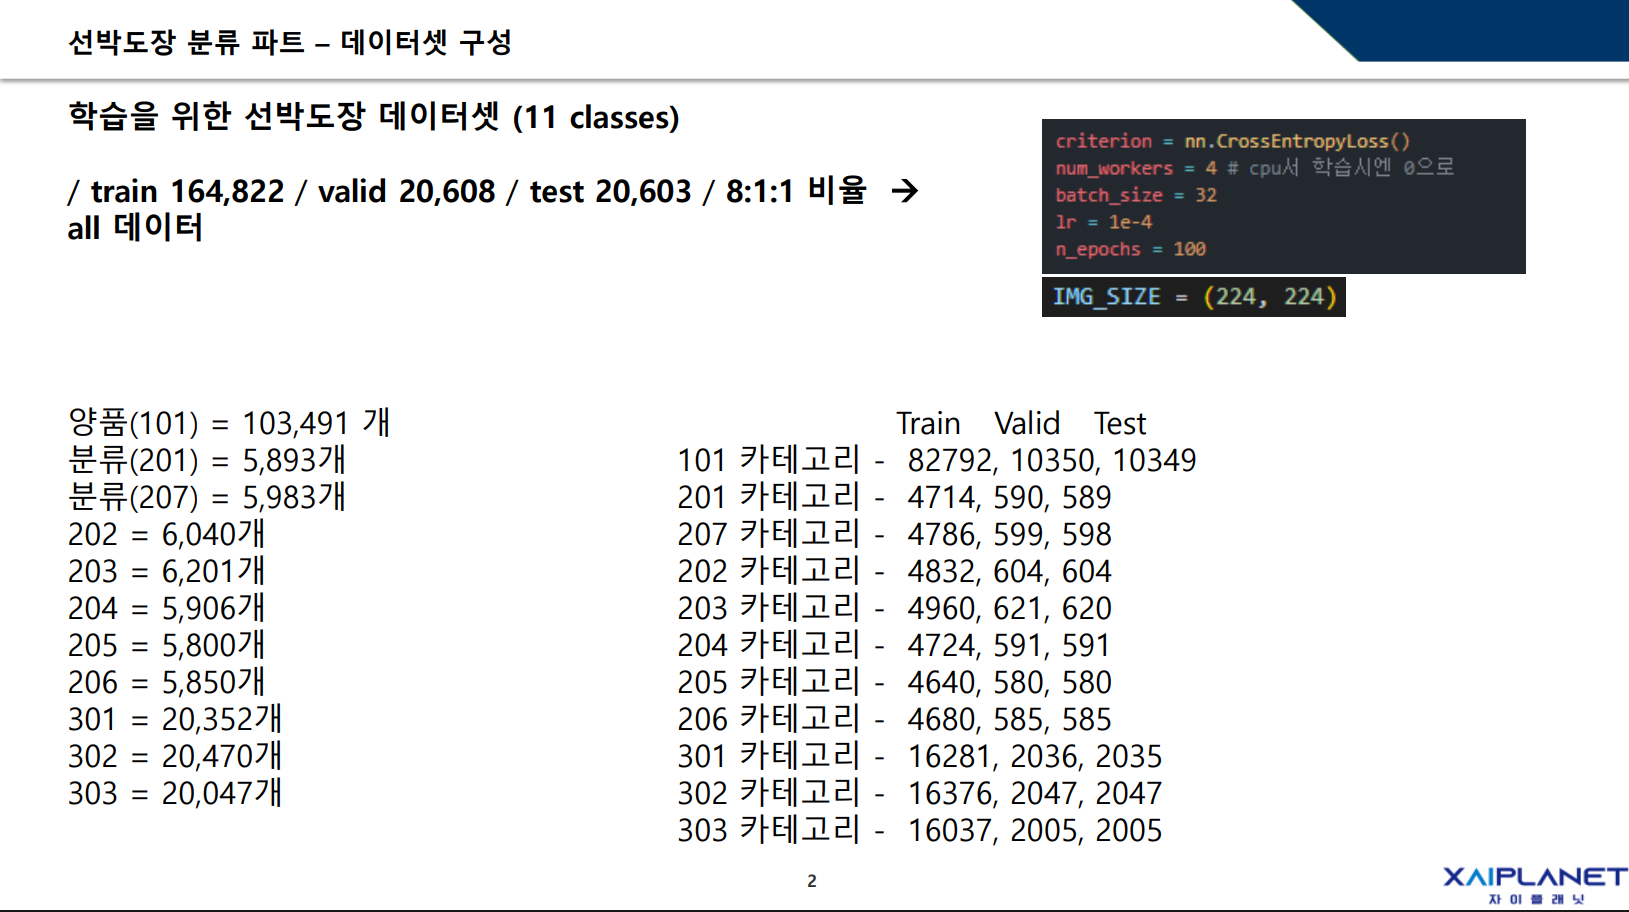

### 💡 [결과 분석] 공식 명세서와 실제 물리적 데이터 수량 차이에 대한 고찰

위 폴더 스캔 코드를 통해 **실제로 각 카테고리별(정상 및 불량 7종) 물리적 이미지 수량과 라벨링(JSON) 파일 수량을 전수 조사하여 대조**한 결과, AI-Hub의 공식 『선박도장 학습 명세서』에 기재된 통계량과 현재 다운로드된 로컬 데이터 간에 일정한 수치 차이가 존재함을 실증적으로 확인했습니다. 
*(예: 균열(Crack) 클래스의 경우 명세서상 5,800장이나, 실제 물리적 데이터는 Train 4,640장 + Valid 580장 = 총 5,220장으로 확인됨)*

이러한 수량 불일치는 데이터의 오류가 아니며, **데이터셋 제공 기관(AI-Hub)의 배포 정책 및 정제 과정**에 기인한 정상적인 현상으로 분석됩니다.

1. **Test-Set 비공개 정책:** 명세서에 기재된 수량은 Train/Valid/Test (8:1:1) 전체를 합산한 수치이나, 현재 실제 배포된 데이터는 평가용 Test-Set(10%)이 제외된 Train(8) : Valid(1) 비율만 제공되고 있습니다.
2. **최종 정제 누락분:** 데이터 구축 단계에서 작성된 명세서(2022.12)와 달리, 최종 업로드 직전에 화질 불량, 라벨링 오류 등의 사유로 일부 데이터가 소거되어 발생하는 전형적인 메타데이터 버전 불일치입니다.

---

### 🎯 본 과제를 위한 데이터 통제 및 밸런싱 전략 (Data Balancing Strategy)

본 연구에서는 모델 아키텍처(YOLO11m vs Swin-YOLO26) 간의 순수한 구조적 성능 비교에 집중하고 다수 클래스 편향을 통제하기 위해, 가장 수량이 적은 **소수 클래스인 '균열(Crack)'의 물리적 총합인 5,220장**을 기준으로 전체 데이터셋을 평탄화(Under-sampling)합니다.

* **Train / Valid / Test 분할 비율:** AI-Hub가 기제공한 격리벽을 준수하면서 자체적인 성능평가셋을 확보하기 위해, 기존 Validation 데이터(580장)를 클래스 비율을 유지하며 정확히 5:5로 분할(Random Split)하여 사용합니다.
* **최종 확정된 클래스별 데이터 세트 구성 (8개 클래스 공통 적용):**
  * **🎈 Train (학습셋):** 4,640 장 (균열 클래스의 Train 전수)
  * **🎈 Valid (검증셋):** 290 장 (기존 Valid 580장의 50%)
  * **🎈 Test (성능평가셋):** 290 장 (기존 Valid 580장의 50%)
  * **📊 클래스별 총합:** 5,220 장 (8개 클래스 통합 총 41,760 장 활용)

---

### 📁 엔지니어링 구현 및 자원 관리 전략 (Engineering Framework)

향후 시간이 허락할 때 진행할 **레거시 모델(Mask R-CNN, DenseNet) 및 기존 타사 베이스라인과의 유연한 비교 검증(Benchmark Flexibility)**을 위해, 물리적인 이미지/라벨 파일의 구조 변경 및 재배치는 일절 진행하지 않습니다. 

물리적 폴더 구조를 임의로 변경할 경우 발생할 수 있는 파일 참조 누수 및 레거시 소스코드 호환성 훼손 리스크를 원천 차단하기 위해 아래와 같은 **'메타데이터 드라이븐(Metadata-driven) 패러다임'**을 채택합니다.

1. **물리 구조 보존:** AI-Hub 원본 다운로드 폴더 구조(`Training/`, `Validation/` 하위 뎁스)를 그대로 유지합니다.
2. **가상 데이터 로더 제어:** 모든 이미지 파싱 및 Train/Valid/Test 데이터 분할은 하드디스크의 파일을 직접 옮기는 방식 대신, 우리가 통합 구축할 단일 메타 마스터 파일인 `ship_paint_annotations.csv` 상에서 샘플링(인덱싱) 행값만 제어하여 가상으로 배분합니다.
3. **폴더 탐색 코드 최적화:** AI 모델의 `Dataset` 및 `DataLoader` 구현 시, 메타 CSV에 저장된 상대 경로 및 파일명을 기반으로 원본 폴더 구조에서 이미지와 JSON 파서를 직접 매핑하도록 설계하여 구조적 안전성과 범용성을 동시에 확보합니다.

## 3-④.💻 [코드 셀] 메타데이터 통합 파싱 (CSV 생성)

In [5]:
import os
import json
import pandas as pd
from tqdm.auto import tqdm

DATASET_ROOT = '../data/01-1.정식개방데이터' 
OUTPUT_CSV = '../data/ship_paint_annotations.csv'

# 타겟 클래스 매핑
TARGET_CATEGORIES = {
    101: '정상(Normal)', 201: '워터스포팅(Water Spotting)', 202: '흐름(Sagging)', 
    203: '도막분리(Peeling)', 204: '핀홀(Pinhole)', 205: '균열(Crack)', 
    206: '부풀음(Blistering)', 207: '이물질포함(Inclusion)'
}

# 모든 이미지 파일의 위치를 빠르게 찾기 위한 딕셔너리 구축
print("🔍 이미지 파일 위치 인덱싱 중...")
img_path_map = {}
for root, _, files in os.walk(DATASET_ROOT):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path_map[f] = os.path.join(root, f)

master_data = []
missing_files = [] # 누락된 파일 기록용

# JSON 파일 수집
json_files = [os.path.join(r, f) for r, _, fs in os.walk(DATASET_ROOT) for f in fs if f.lower().endswith('.json')]

print(f"🚀 총 {len(json_files):,}개 JSON 파싱 시작...")

for j_file in tqdm(json_files):
    with open(j_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        # 이미지 정보 맵핑
        img_info_map = {img['id']: img['file_name'] for img in data.get('images', [])}
            
        for anno in data.get('annotations', []):
            cat_id = anno.get('category_id')
            if cat_id in TARGET_CATEGORIES:
                file_name = img_info_map.get(anno['image_id'])
                
                # [핵심 검증] 실제 이미지 경로가 존재하는가?
                actual_path = img_path_map.get(file_name)
                
                if actual_path and os.path.exists(actual_path):
                    bbox = anno.get('bbox', [0, 0, 0, 0])
                    master_data.append({
                        'image_id': anno['image_id'],
                        'file_name': file_name,
                        'relative_path': actual_path,
                        'category_id': cat_id,
                        'category_name': TARGET_CATEGORIES[cat_id],
                        'bbox': bbox
                    })
                else:
                    # 파일이 없으면 기록
                    if file_name not in missing_files:
                        missing_files.append(file_name)

# 결과 저장
df = pd.DataFrame(master_data)
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')


print(f"🎉 추출 완료! 총 {len(df):,}행 저장 -> {OUTPUT_CSV}")
print(f"✅ 유효 객체 수: {len(df):,}")
print(f"⚠️ 누락된 파일 수: {len(missing_files):,}")
if missing_files:
    print(f"👉 누락된 파일 예시: {missing_files[:5]}")

🔍 이미지 파일 위치 인덱싱 중...
🚀 총 74,625개 JSON 파싱 시작...


100%|██████████| 74625/74625 [00:15<00:00, 4698.32it/s]


🎉 추출 완료! 총 80,525행 저장 -> ../data/ship_paint_annotations.csv
✅ 유효 객체 수: 80,525
⚠️ 누락된 파일 수: 0
